# Recipe 10 — Filter Tracks by Metadata, Find Regional Overlaps, Extract Intervals

Joins two FILER endpoints into a single row-per-interval table:

1. **Build a metadata filter** — translate convenience flags (assay, tissue, etc.)
   into a jq boolean expression
2. **Recipe 3** — query the coordinate endpoint with that filter to find tracks
   that both match biological criteria AND overlap the region of interest
3. **Rank** — sort by `num_overlaps`, keep top N
4. **Recipe 2** — fetch the actual overlapping intervals from those top N tracks
5. **Join** — attach full track metadata to every interval row

**Use when:** you have both a biological question (e.g. "ENCODE ATAC-seq blood tracks")
and a genomic locus of interest (e.g. a GWAS hit), and you want the actual peak
intervals from the most relevant tracks at that locus.

> **Note:** Earlier versions of this notebook ran Recipe 1 (metadata search) and
> Recipe 3 separately and intersected the results. With `fullMetadata=1`, Recipe 3
> already returns full metadata for each overlapping track, so the separate Recipe 1
> step is redundant — applying the same jq filter to Recipe 3 produces an identical
> track set in fewer API calls.

Prerequisites:
  source venv/bin/activate
  pip install -e .

No authentication required for public FILER data.

---
## 0. Setup

In [ ]:
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timezone

from filerpy.client import (
    get_overlapping_tracks,
    fetch_overlaps,
    ENDPOINTS,
)

In [ ]:
print(f"Region overlaps endpoint: {ENDPOINTS['region_overlaps']}")
print(f"Overlaps endpoint:        {ENDPOINTS['overlaps']}")

---
## 1. Configure your query

Edit the parameters in this section. Everything else runs without changes.

### Shared parameters

| Parameter    | Example values          | Required |
|---|---|---|
| GENOME_BUILD | `hg19`, `hg38`          | Yes      |
| REGION       | `chr1:100000-200000`    | Yes      |
| TOP_N        | `100` (default)         | No       |
| CHUNK_SIZE   | `250` (default)         | No       |

In [ ]:
# ── Shared ───────────────────────────────────────────────────────────────────
GENOME_BUILD = "hg38"                     # "hg38" or "hg19"
REGION       = "chr19:44905791-44909393"  # chrN:start-end
TOP_N        = 100                        # keep top N tracks by num_overlaps
CHUNK_SIZE   = 250                        # IDs per request to the overlaps endpoint

# ── Metadata filters: convenience flags (ignored when FILTER_STRING is non-empty) ──
ASSAY           = "ATAC-seq"  # e.g. "ATAC-seq", "ChIP-seq", or "" to skip
CELL_TYPE       = ""          # e.g. "CD14+ monocyte"
TISSUE_CATEGORY = "Blood"     # e.g. "Blood", "Brain"
DATA_SOURCE     = ""          # e.g. "ENCODE", "Blueprint"
TRACK_ID        = ""          # specific track ID, or ""

# ── Metadata filters: raw jq filter (overrides convenience flags when non-empty) ──
FILTER_STRING = ""
# Example: '.data_source == "ENCODE" and .assay == "ATAC-seq"'
# Example: '(.data_source == "ENCODE" or .data_source == "Blueprint") and .assay == "ATAC-seq"'

# ── Output ────────────────────────────────────────────────────────────────────
SAVE_JSON = True   # also write results.json alongside results.tsv

---
## 2. Hello World — quick connection check

Verify your connection against two known tracks before running the full workflow.

In [4]:
df_hello = fetch_overlaps(
    region="chr19:44905791-44909393",
    ids=["NGBLPL2W2SM2WC", "NGENCC4CIT5FBQ"],
)
print(f"Connection OK — intervals returned: {len(df_hello)}")
print(df_hello.head().to_string())

Connection OK — intervals returned: 5
       Identifier              queryRegion                                                                                    hitString
0  NGBLPL2W2SM2WC  chr19:44905791-44909393            chr19@@@44906965@@@44910985@@@GC_T14_11.hyper_meth.bs_call.GRCh38.20150707_656194
1  NGENCC4CIT5FBQ  chr19:44905791-44909393     chr19@@@44905261@@@44906731@@@Peak_166852@@@200@@@.@@@2.0074@@@20.09425@@@18.16041@@@983
2  NGENCC4CIT5FBQ  chr19:44905791-44909393  chr19@@@44905261@@@44906731@@@Peak_47929@@@1000@@@.@@@4.28511@@@138.50365@@@135.95485@@@401
3  NGENCC4CIT5FBQ  chr19:44905791-44909393    chr19@@@44905261@@@44906731@@@Peak_71166@@@837@@@.@@@3.27742@@@83.75295@@@81.40279@@@1281
4  NGENCC4CIT5FBQ  chr19:44905791-44909393     chr19@@@44905261@@@44906731@@@Peak_93882@@@552@@@.@@@2.85754@@@55.24267@@@53.03147@@@726


---
## 3. Step 1 — Build the metadata filter

Translate the convenience flags (`ASSAY`, `TISSUE_CATEGORY`, etc.) into a jq
boolean expression that will be applied server-side by the coordinate endpoint.
If `FILTER_STRING` is set, it overrides the convenience flags.

In [ ]:
# Map convenience flag names → jq metadata field expressions
JQ_FIELD_MAP = {
    "assay":           ".assay",
    "cell_type":       ".cell_type",
    "tissue_category": ".tissue_category",
    "data_source":     ".data_source",
    "track_id":        ".identifier",
}


def build_filter_string(named: dict) -> str:
    """Combine non-empty named filters into a jq boolean expression joined with `and`."""
    clauses = [f'{JQ_FIELD_MAP[k]} == "{v}"' for k, v in named.items() if v]
    return " and ".join(clauses) if clauses else "."


if FILTER_STRING:
    filter_string = FILTER_STRING
    print(f"Using raw filter: {filter_string}")
else:
    filter_string = build_filter_string({
        "assay":           ASSAY,
        "cell_type":       CELL_TYPE,
        "tissue_category": TISSUE_CATEGORY,
        "data_source":     DATA_SOURCE,
        "track_id":        TRACK_ID,
    })
    print(f"Built filter from convenience flags: {filter_string}")

---
## 4. Step 2 — Recipe 3: coordinate search with metadata filter

Find tracks whose intervals overlap the region AND match the metadata filter built
in Step 1. Always uses `fullMetadata=1` so `num_overlaps` and all metadata fields
are available for ranking and downstream use.
Time: 5–60 seconds depending on region size and server load.

In [ ]:
print(f"Querying coordinate endpoint for: {REGION}  (build: {GENOME_BUILD})")
print(f"filterString: {filter_string}")

raw_r3 = get_overlapping_tracks(
    region=REGION,
    genome_build=GENOME_BUILD,
    filterString=filter_string,
    fullMetadata=1,
    countOnly=0,
)

df_r3 = pd.DataFrame(raw_r3) if raw_r3 else pd.DataFrame()
print(f"\nRecipe 3 — overlapping tracks returned: {len(df_r3)}")

if df_r3.empty:
    print("WARNING: no overlapping tracks found. Check your region string and filter.")
else:
    show = [c for c in ["identifier", "num_overlaps", "assay", "tissue_category", "data_source"] if c in df_r3.columns]
    print(df_r3[show].sort_values("num_overlaps", ascending=False).head(10).to_string())

---
## 5. Step 3 — Rank by num_overlaps and keep top N

Sort the Recipe 3 results by `num_overlaps` descending and keep the top `TOP_N`
tracks. These are the tracks both biologically relevant to your filter AND most
active at your locus.

In [ ]:
if df_r3.empty:
    raise RuntimeError(
        "Recipe 3 returned no results. Fix the warnings in section 4 before continuing."
    )

if "num_overlaps" in df_r3.columns:
    df_ranked = df_r3.sort_values("num_overlaps", ascending=False)
else:
    print("WARNING: num_overlaps not in response — ordering may be arbitrary.")
    df_ranked = df_r3.copy()

print(f"Recipe 3 tracks   : {len(df_r3)}")
print(f"Selecting top N   : {min(TOP_N, len(df_ranked))}")

In [ ]:
top_tracks = df_ranked.head(TOP_N).reset_index(drop=True)

show = [c for c in ["identifier", "num_overlaps", "assay", "tissue_category", "data_source", "track_name"] if c in top_tracks.columns]
print(f"\nTop {len(top_tracks)} tracks:")
print(top_tracks[show].head(20).to_string())

---
## 6. Step 4 — Recipe 2: fetch overlapping intervals

Query the FILER overlaps endpoint to pull the actual genomic intervals (peaks, etc.)
from the top N tracks that fall within the region.
Time: ~1–2 seconds per batch of 250 tracks; expect ~1 min per 250 tracks total.

In [11]:
track_ids = top_tracks["identifier"].tolist()
n_batches = -(-len(track_ids) // CHUNK_SIZE)  # ceiling division

print(f"Region  : {REGION}")
print(f"Tracks  : {len(track_ids)}")
print(f"Batches : {n_batches} × {CHUNK_SIZE}")

Region  : chr19:44905791-44909393
Tracks  : 100
Batches : 1 × 250


In [12]:
df_r2 = fetch_overlaps(region=REGION, ids=track_ids, chunk_size=CHUNK_SIZE)

print(f"\nRecipe 2 — overlapping intervals returned: {len(df_r2)}")
if df_r2.empty:
    print("WARNING: no intervals returned. The tracks may have no features in this region.")
else:
    print(df_r2.head(10).to_string())


Recipe 2 — overlapping intervals returned: 370
       Identifier              queryRegion                                                                                                                                                                                            hitString
0  NGADBEUSWAG2JJ  chr19:44905791-44909393    chr19@@@44906652@@@44906665@@@chr19@@@45409909@@@45409922@@@TEAD2@@@64@@@+@@@MA1121.1@@@15.9909@@@3.23e-07@@@TCACATTCCTGGC@@@chr19:44906475-44906757;266_23257;64;.;4.21633;8.75231;6.49937;66;13
1  NGADBEUSWAG2JJ  chr19:44905791-44909393  chr19@@@44906668@@@44906685@@@chr19@@@45409925@@@45409942@@@SP4@@@76@@@-@@@MA0685.1@@@22.6727@@@2.46e-08@@@CAAGCCCCGCCCCCATA@@@chr19:44906475-44906757;266_23257;64;.;4.21633;8.75231;6.49937;66;17
2  NGADBEUSWAG2JJ  chr19:44905791-44909393  chr19@@@44906669@@@44906686@@@chr19@@@45409926@@@45409943@@@SP2@@@76@@@-@@@MA0516.2@@@22.1818@@@2.21e-08@@@GCAAGCCCCGCCCCCAT@@@chr19:44906475-44906757;266_23257;64;.;4.21633;8.75231;6.4993

---
## 7. Step 5 — Join intervals with track metadata

Left-join Recipe 2 interval rows with ranked track metadata.
Result: one row per interval with full track metadata attached.

In [13]:
# Normalise identifier column capitalisation before joining
if "Identifier" in df_r2.columns and "identifier" not in df_r2.columns:
    df_r2 = df_r2.rename(columns={"Identifier": "identifier"})

final = df_r2.merge(top_tracks, on="identifier", how="left")

# Preferred column order: identity → queryRegion → hitString → metadata
front_cols = ["identifier", "queryRegion", "hitString"]
meta_cols  = [c for c in top_tracks.columns if c != "identifier"]
ordered    = front_cols + [c for c in meta_cols if c in final.columns]
extra      = [c for c in final.columns if c not in ordered]
final      = final[ordered + extra]

print(f"Final table: {len(final)} rows × {len(final.columns)} columns")
show = [c for c in ["identifier", "queryRegion", "hitString", "num_overlaps", "assay", "tissue_category", "data_source"] if c in final.columns]
print(final[show].head(10).to_string())

Final table: 370 rows × 34 columns
       identifier              queryRegion                                                                                                                                                                                            hitString  num_overlaps     assay tissue_category   data_source
0  NGADBEUSWAG2JJ  chr19:44905791-44909393    chr19@@@44906652@@@44906665@@@chr19@@@45409909@@@45409922@@@TEAD2@@@64@@@+@@@MA1121.1@@@15.9909@@@3.23e-07@@@TCACATTCCTGGC@@@chr19:44906475-44906757;266_23257;64;.;4.21633;8.75231;6.49937;66;13            11  ATAC-seq           Blood  ATACdb_v1.03
1  NGADBEUSWAG2JJ  chr19:44905791-44909393  chr19@@@44906668@@@44906685@@@chr19@@@45409925@@@45409942@@@SP4@@@76@@@-@@@MA0685.1@@@22.6727@@@2.46e-08@@@CAAGCCCCGCCCCCATA@@@chr19:44906475-44906757;266_23257;64;.;4.21633;8.75231;6.49937;66;17            11  ATAC-seq           Blood  ATACdb_v1.03
2  NGADBEUSWAG2JJ  chr19:44905791-44909393  chr19@@@44906669@@@44906686@@@chr19@@@4

---
## 8. Explore the results

Sections 8a–8c break down interval counts by assay, cell_type, and tissue_category.
Each category gets a count table and a bar chart. Sections 8d–8e cover the per-track
interval distribution and hitString token counts.

### 8a. Intervals by assay

In [14]:
if "assay" in final.columns:
    assay_counts = final["assay"].value_counts()
    print("=== Intervals by assay ===")
    print(assay_counts.to_string())
else:
    print("Column 'assay' not present in final table — skipping.")
    assay_counts = pd.Series(dtype=int)

=== Intervals by assay ===
assay
ATAC-seq    370


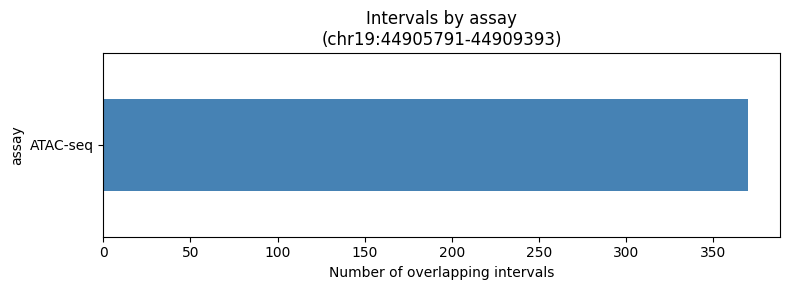

In [15]:
if not assay_counts.empty:
    fig, ax = plt.subplots(figsize=(8, max(3, len(assay_counts) * 0.4)))
    assay_counts.sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set_xlabel("Number of overlapping intervals")
    ax.set_title(f"Intervals by assay\n({REGION})")
    plt.tight_layout()
    plt.show()

### 8b. Intervals by cell_type

In [16]:
if "cell_type" in final.columns:
    cell_counts = final["cell_type"].value_counts()
    print("=== Intervals by cell_type ===")
    print(cell_counts.to_string())
else:
    print("Column 'cell_type' not present in final table — skipping.")
    cell_counts = pd.Series(dtype=int)

=== Intervals by cell_type ===
cell_type
K562                                            143
Lower motor neurons                             123
Jurkat                                           22
CD8+ alpha-beta naive T cell                     18
Naive T effector cells                           11
Naive B cell                                     11
CD4+ alpha-beta naive T cell                     11
Follicular T helper                              10
T-cell                                            9
Naive thymus-derived CD8+, alpha-beta T cell      6
Dendritic cell                                    3
CD4+ CD25+ alpha-beta Treg                        3


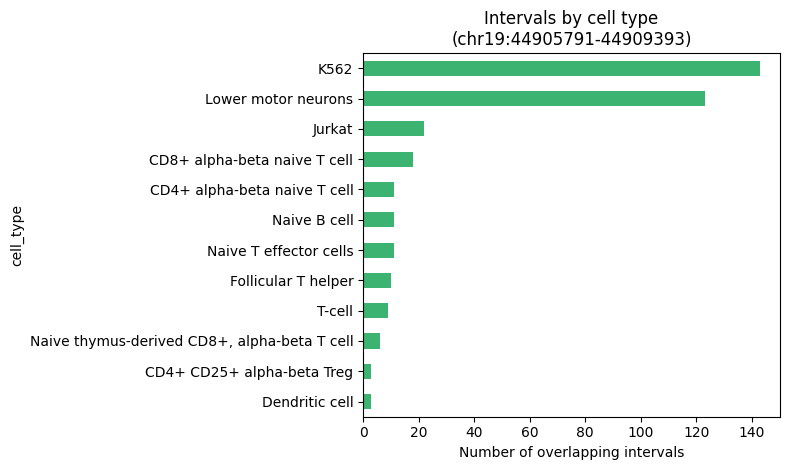

In [17]:
if not cell_counts.empty:
    fig, ax = plt.subplots(figsize=(8, max(3, len(cell_counts) * 0.4)))
    cell_counts.sort_values().plot.barh(ax=ax, color="mediumseagreen")
    ax.set_xlabel("Number of overlapping intervals")
    ax.set_title(f"Intervals by cell type\n({REGION})")
    plt.tight_layout()
    plt.show()

### 8c. Intervals by tissue_category

In [18]:
if "tissue_category" in final.columns:
    tissue_counts = final["tissue_category"].value_counts()
    print("=== Intervals by tissue_category ===")
    print(tissue_counts.to_string())
else:
    print("Column 'tissue_category' not present in final table — skipping.")
    tissue_counts = pd.Series(dtype=int)

=== Intervals by tissue_category ===
tissue_category
Blood    370


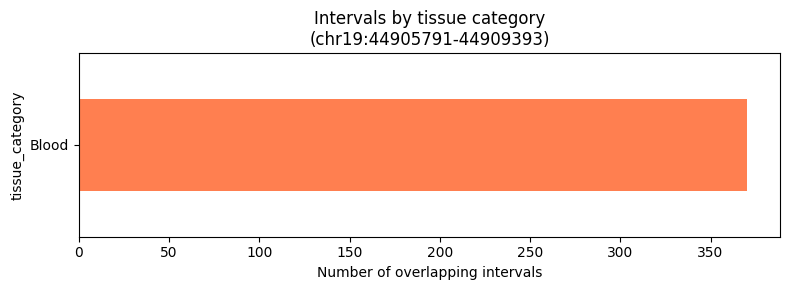

In [19]:
if not tissue_counts.empty:
    fig, ax = plt.subplots(figsize=(8, max(3, len(tissue_counts) * 0.4)))
    tissue_counts.sort_values().plot.barh(ax=ax, color="coral")
    ax.set_xlabel("Number of overlapping intervals")
    ax.set_title(f"Intervals by tissue category\n({REGION})")
    plt.tight_layout()
    plt.show()

### 8d. Intervals per track (top 20)

In [20]:
print("=== Intervals per track (top 20) ===")
print(final["identifier"].value_counts().head(20).to_string())

=== Intervals per track (top 20) ===
identifier
NGADBEUSWAG2JJ    11
NGADB6YKIHUELS    11
NGADBDDFETQ6JO    11
NGADBNLBQL2Z2Q    10
NGENCWRKNQBTAH     4
NGENCJQ735ZCJU     4
NGENCDN32QGOSC     4
NGENCV5RF6RS7F     4
NGENCY3GCMAGL4     4
NGENCE4K53IRFQ     4
NGENCMBRVYIDDX     4
NGENCVPIRW6KTM     4
NGENCF2ISBSJZ2     4
NGENCD5HVVDEDW     4
NGENCGDMF26MYW     4
NGENCGFXKV5MB5     4
NGENCALOQ2LCZA     4
NGENCEVIZOQ3EP     4
NGENCVUSEK3FEC     4
NGENC2TLWSORM6     4


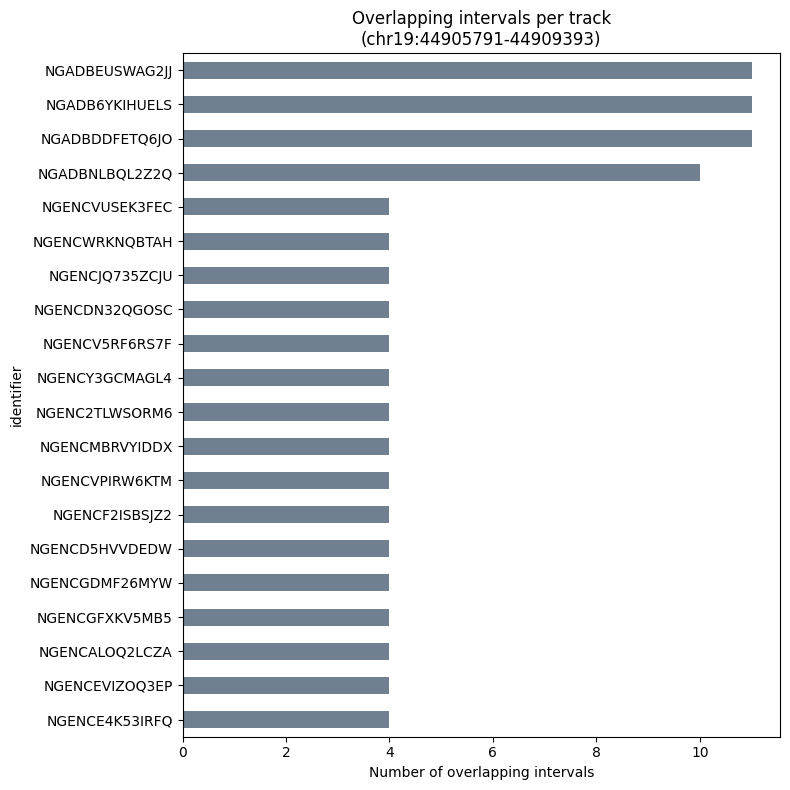

In [21]:
counts = final["identifier"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(8, max(3, len(counts) * 0.4)))
counts.sort_values().plot.barh(ax=ax, color="slategrey")
ax.set_xlabel("Number of overlapping intervals")
ax.set_title(f"Overlapping intervals per track\n({REGION})")
plt.tight_layout()
plt.show()

### 8e. hitString token count distribution

In [22]:
if "hitString" in final.columns:
    hit_lens = final["hitString"].astype(str).str.split("@@@").str.len()
    print("=== hitString token count distribution ===")
    print(hit_lens.describe())

=== hitString token count distribution ===
count    370.000000
mean      10.464865
std        1.283672
min       10.000000
25%       10.000000
50%       10.000000
75%       10.000000
max       14.000000
Name: hitString, dtype: float64


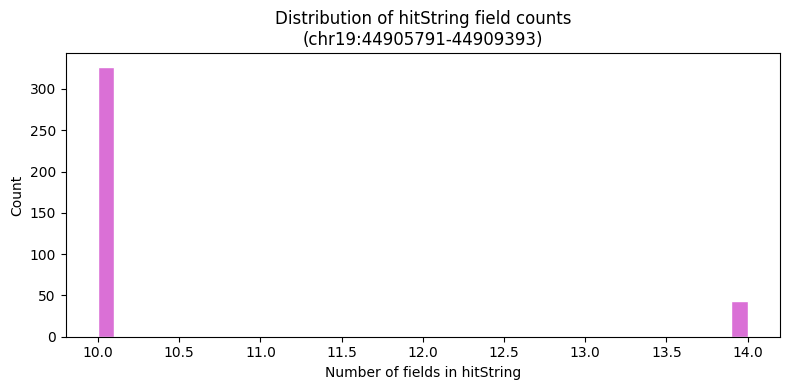

In [23]:
if "hitString" in final.columns:
    hit_lens = final["hitString"].astype(str).str.split("@@@").str.len()
    fig, ax = plt.subplots(figsize=(8, 4))
    hit_lens.plot.hist(ax=ax, bins=40, color="orchid", edgecolor="white")
    ax.set_xlabel("Number of fields in hitString")
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of hitString field counts\n({REGION})")
    plt.tight_layout()
    plt.show()

---
## 9. Refine your selection

Post-query filtering — narrow by hitString contents, token count, or specific tracks.
Edit the conditions below to match what you need.

In [24]:
df_filtered = final.copy()

# ── Edit these conditions ────────────────────────────────────────────────────
# Keep only rows with >= 3 fields in hitString
if "hitString" in df_filtered.columns:
    hit_lens = df_filtered["hitString"].astype(str).str.split("@@@").str.len()
    df_filtered = df_filtered[hit_lens >= 3]

# Keep only rows whose hitString contains "Peak"
if "hitString" in df_filtered.columns and df_filtered["hitString"].astype(str).str.contains("Peak", na=False).any():
    df_filtered = df_filtered[df_filtered["hitString"].astype(str).str.contains("Peak", na=False)]
# ─────────────────────────────────────────────────────────────────────────────

key_cols = [c for c in ["identifier", "queryRegion", "hitString"] if c in df_filtered.columns]
print(f"After refinement: {len(df_filtered)} intervals (from {len(final)} total)")
print(df_filtered[key_cols].head().to_string())

After refinement: 210 intervals (from 370 total)
        identifier              queryRegion                                                                                  hitString
43  NGENCWRKNQBTAH  chr19:44905791-44909393  chr19@@@44905488@@@44906340@@@Peak_114913@@@763@@@.@@@2.64034@@@76.35685@@@74.22697@@@282
44  NGENCWRKNQBTAH  chr19:44905791-44909393  chr19@@@44905488@@@44906340@@@Peak_128978@@@617@@@.@@@2.44541@@@61.77099@@@59.69475@@@587
45  NGENCWRKNQBTAH  chr19:44905791-44909393  chr19@@@44905488@@@44906340@@@Peak_149729@@@467@@@.@@@2.22895@@@46.75123@@@44.74239@@@486
46  NGENCWRKNQBTAH  chr19:44905791-44909393  chr19@@@44906432@@@44906726@@@Peak_22160@@@1000@@@.@@@7.2358@@@699.4527@@@696.52844@@@127
55  NGENCV5RF6RS7F  chr19:44905791-44909393  chr19@@@44905278@@@44906694@@@Peak_156341@@@586@@@.@@@3.86695@@@58.69168@@@56.74157@@@984


---
## 10. Save results

In [25]:
repo_root = Path().resolve().parents[1]
out_dir   = repo_root / "output" / "10-filter-then-overlaps"
out_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {out_dir}")

Output directory: /Users/divak2004/Documents/GitHub/FILER-workflows/output/10-filter-then-overlaps


### 10a. Save final joined table as TSV

In [26]:
tsv_path = out_dir / "results.tsv"
df_filtered.to_csv(tsv_path, sep="\t", index=False)
print(f"Saved {len(df_filtered)} intervals → {tsv_path}")

Saved 210 intervals → /Users/divak2004/Documents/GitHub/FILER-workflows/output/10-filter-then-overlaps/results.tsv


### 10b. Save as JSON (optional)

In [27]:
if SAVE_JSON:
    json_path = out_dir / "results.json"
    df_filtered.to_json(json_path, orient="records", indent=2)
    print(f"Saved JSON → {json_path}")
else:
    print("SAVE_JSON=False — skipping JSON output")

Saved JSON → /Users/divak2004/Documents/GitHub/FILER-workflows/output/10-filter-then-overlaps/results.json


### 10c. Save query provenance

In [ ]:
provenance = {
    "query": {
        "genome_build":   GENOME_BUILD,
        "region":         REGION,
        "top_n":          TOP_N,
        "chunk_size":     CHUNK_SIZE,
        "filter_string":  filter_string,
    },
    "results": {
        "r3_tracks":          len(df_r3),
        "top_tracks_queried": len(top_tracks),
        "total_intervals":    len(final),
        "after_refinement":   len(df_filtered),
    },
    "timestamp": datetime.now(timezone.utc).isoformat(),
}

prov_path = out_dir / "provenance.json"
prov_path.write_text(json.dumps(provenance, indent=2))
print(f"Provenance saved → {prov_path}")
print(json.dumps(provenance, indent=2))

---
## 11. Next steps

You now have `results.tsv`, optionally `results.json`, and `provenance.json`
in `output/10-filter-then-overlaps/`.

| What to do next                                | Recipe / Notebook                  |
|---|---|
| Find and filter tracks before querying         | Recipe 1 / 01_track_discovery.py   |
| Extract intervals from a known track set       | Recipe 2 / 02_track_overlaps.py    |
| Discover tracks by region, no pre-selected IDs | Recipe 3 / 03_coordinate_search.py |
| Summarise overlaps by assay / cell type        | Recipe 4.1                         |

Quick reference — reload your saved results in a future session:

  import pandas as pd
  df = pd.read_csv("output/10-filter-then-overlaps/results.tsv", sep="\t")
  print(df.head())